<a href="https://colab.research.google.com/github/hamza-bangash/Ai_course/blob/main/CNN/lions_cheetahs_imageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from PIL import Image
from tensorflow import keras
from keras import layers,Sequential
from keras.layers import Conv2D, Flatten, Dense

# **Lions or Cheetahs - Image Classification**

## Downlad data Sets

In [2]:
!pip install kaggle --quiet

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hamzabangash1","key":"bf2ca98470c38c5e1d6d788919559588"}'}

In [4]:
!mkdir ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download mikoajfish99/lions-or-cheetahs-image-classification

Dataset URL: https://www.kaggle.com/datasets/mikoajfish99/lions-or-cheetahs-image-classification
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/71.3M [00:00<?, ?B/s]
100% 71.3M/71.3M [00:00<00:00, 1.32GB/s]


In [6]:
!unzip -q lions-or-cheetahs-image-classification.zip -d data/

In [7]:
!find data -maxdepth 2 -type d | head -n 20

data
data/images
data/images/Cheetahs
data/images/Lions


## Checking Corrupt Files

In [8]:
import os
from PIL import Image

In [9]:
badfile=0

for dirpath,_,filenames in os.walk("data/images/"):
  for f in filenames:
    p = os.path.join(dirpath,f)
    try:
        Image.open(p).verify()
    except Exception:
      badfile+=1
      try:
        os.remove(p)
      except Exception:
        pass
print(badfile)


0


## LoadData

In [10]:
train_ds = keras.utils.image_dataset_from_directory(
    "data/images/"
    ,validation_split=0.2
    ,subset='training'
    ,image_size=(224,224)
    ,batch_size=32
    ,shuffle=True
    ,seed=123
)

val_ds = keras.utils.image_dataset_from_directory(
    "data/images/"
    ,validation_split=0.2
    ,subset='validation'
    ,image_size=(224,224)
    ,batch_size=32
    ,shuffle=True
    ,seed=123
)

Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.


## Data Augamentation

In [11]:
data_augamentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x,y: (data_augamentation(x),y))

## Normalization

In [12]:
norm_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x,y: (norm_layer(x),y))
val_ds = val_ds.map(lambda x,y: (norm_layer(x),y))

## Improve Performance with Caching & Prefetch

In [13]:
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds  = val_ds.cache().prefetch(tf.data.AUTOTUNE)

# **Models**

In [14]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',strides=(2,2),activation='relu',input_shape=(224,224,3)))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',strides=(2,2),activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',strides=(2,2),activation='relu'))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 111, 111, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 55, 55, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 27, 27, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 23328)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,986,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,015,873 (11.50 MB)

 Trainable params: 3,015,873 (11.50 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
history = model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 778ms/step - accuracy: 0.5032 - loss: 0.7553 - val_accuracy: 0.5000 - val_loss: 0.6862
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4574 - loss: 0.7076 - val_accuracy: 0.5000 - val_loss: 0.6880
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5126 - loss: 0.6920 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4797 - loss: 0.6961 - val_accuracy: 0.6000 - val_loss: 0.6876
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8302 - loss: 0.6621 - val_accuracy: 0.5000 - val_loss: 0.6850
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5466 - loss: 0.6868 - val_accuracy: 0.5000 - val_loss: 0.6774
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6707 - loss: 0.6376 - val_accuracy: 0.5000 - val_loss: 0.6663
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6654 - loss: 0.6040 - val_accuracy: 0.4750 - val_loss: 0.653

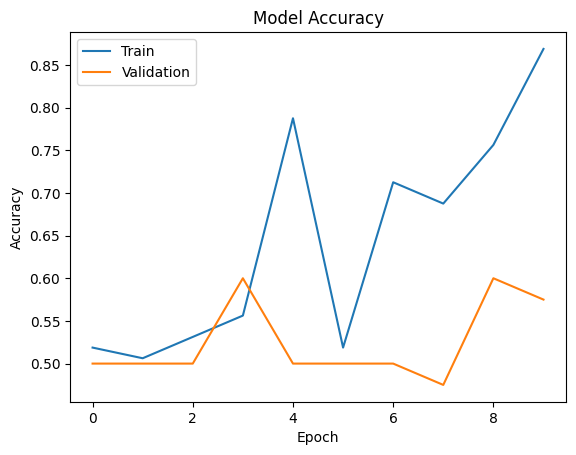

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc='upper left')
plt.show()